TASK 1: TRAINING ANN REGRESSOR FOR PREMIUM PREDICTION
Training ANN Regressor...
Epoch 1/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 51664.3867 - mae: 51664.3867 - val_loss: 57041.5859 - val_mae: 57041.5859
Epoch 2/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51122.5977 - mae: 51122.5977 - val_loss: 56045.7656 - val_mae: 56045.7656
Epoch 3/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 49456.1836 - mae: 49456.1836 - val_loss: 53272.5273 - val_mae: 53272.5273
Epoch 4/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 45961.9258 - mae: 45961.9258 - val_loss: 47819.4648 - val_mae: 47819.4648
Epoch 5/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 40435.1953 - mae: 40435.1953 - val_loss: 42069.5039 - val_mae: 42069.5039
Epoch 6/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 34996.3633 - mae: 34996.3633 - val_loss: 38374.9453 - val_mae: 38374.9453
Epoch 7/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32256.2129 - mae: 32256.2129 - val_loss: 36020.98

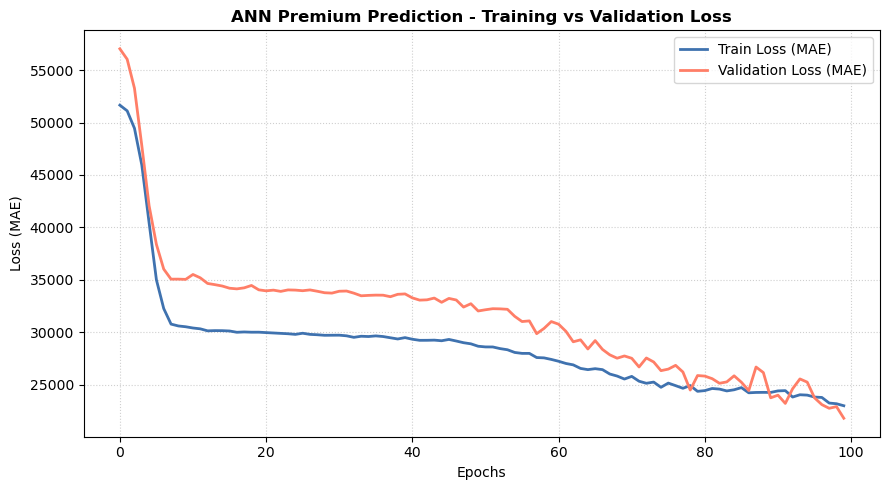

Saved ANN Regressor to: C:\Users\Prasanth Rajaram\OneDrive\Desktop\project\InsureAI\models\premium_ann_model.keras

TASK 2: TRAINING ANN CLASSIFIER FOR CLAIMS FRAUD DETECTION
Applying SMOTE on Training Data...
Training ANN Classifier...
Epoch 1/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7681 - loss: 0.4807 - val_accuracy: 0.7746 - val_loss: 0.5346
Epoch 2/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8092 - loss: 0.4135 - val_accuracy: 0.7684 - val_loss: 0.5293
Epoch 3/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8181 - loss: 0.4020 - val_accuracy: 0.7949 - val_loss: 0.4791
Epoch 4/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8234 - loss: 0.3930 - val_accuracy: 0.8015 - val_loss: 0.4827
Epoch 5/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8275 - loss: 0.3864 - val_accuracy: 0.8143 - val_loss: 0.4434
Epoch 6/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8342 - loss: 0.3766 - val_accuracy: 0.8579 - val_lo

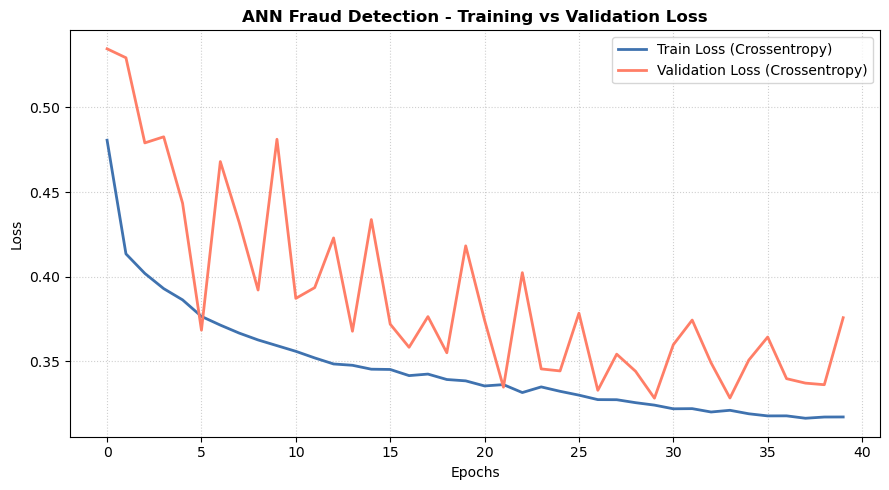

Saved ANN Classifier to: C:\Users\Prasanth Rajaram\OneDrive\Desktop\project\InsureAI\models\fraud_ann_model.keras

COMPARISON TABLES: MODULE 1 (CLASSICAL ML) vs. MODULE 2 (DEEP LEARNING ANN)

--- PREMIUM PREDICTION (REGRESSION) COMPARISON ---
                           Model  R2 Score  MAE (INR)
               Linear Regression    0.1009   79458.26
         Random Forest Regressor    0.9396    7592.33
               XGBoost Regressor    0.9309   11375.57
ANN Regressor (Keras/TensorFlow)    0.4581   17698.13

--- FRAUD DETECTION (CLASSIFICATION) COMPARISON ---
                       Classifier  Accuracy  Precision  Recall  F1-Score
   Logistic Regression (Balanced)    0.7998     0.4904  0.7985    0.6076
            Random Forest (SMOTE)    0.8636     0.6621  0.6076    0.6337
       XGBoost Classifier (SMOTE)    0.8755     0.6868  0.6591    0.6727
ANN Classifier (Keras/TensorFlow)    0.8607     0.6227  0.7162    0.6662




In [1]:
# =====================================================================
# MODULE 2: DEEP LEARNING (ANN) - COMPLETE PIPELINE
# =====================================================================

# 1. SETUP IMPORTS & KERAS BACKEND
try:
    import google.protobuf.runtime_version as _runtime_version
    _runtime_version.ValidateProtobufRuntimeVersion = lambda *args, **kwargs: None
except Exception:
    pass

import os
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

os.environ['KERAS_BACKEND'] = 'tensorflow'
import tensorflow as tf
import keras
from keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# 2. RESOLVE WORKSPACE PATHS
BASE_DIR = r"C:\Users\Prasanth Rajaram\OneDrive\Desktop\project\InsureAI"
if not os.path.exists(BASE_DIR):
    BASE_DIR = r"C:\Users\Prasanth Rajaram\InsureAI_Local"
    
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# 3. TASK 1: ANN REGRESSOR FOR PREMIUM PREDICTION (REGRESSION)
def train_regression_ann():
    print("=" * 80)
    print("TASK 1: TRAINING ANN REGRESSOR FOR PREMIUM PREDICTION")
    print("=" * 80)
    
    df = pd.read_csv(os.path.join(PROCESSED_DIR, "insurance_cleaned.csv"))
    X = df.drop(columns=['customer_id', 'annual_premium_inr'])
    y = df['annual_premium_inr']
    
    num_cols = ['age', 'bmi', 'children', 'annual_income_inr', 'smoker']
    cat_cols = ['gender', 'region', 'occupation', 'exercise_frequency', 
                'alcohol_consumption', 'medical_history', 'family_medical_history']
    
    for col in num_cols:
        if col == 'smoker' and X[col].dtype == 'object':
            X[col] = (X[col].astype(str).str.lower() == 'yes').astype(float)
        else:
            X[col] = pd.to_numeric(X[col], errors='coerce')

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype(str)

    # Train / Test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Fit ColumnTransformer directly on X_train (prevents category/dtype mismatches)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)
    
    joblib.dump(preprocessor, os.path.join(MODEL_DIR, "premium_preprocessor.joblib"))
    
    # Build Keras ANN Model (3 Hidden Layers with ReLU)
    model = models.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mae', metrics=['mae'])
    
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True
    )
    
    print("Training ANN Regressor...")
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=1
    )
    
    y_pred = model.predict(X_test_scaled).flatten()
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\nANN Regressor Results:\n  R2 Score: {r2:.4f}\n  MAE: INR {mae:,.2f}\n  RMSE: INR {rmse:,.2f}\n")
    
    plt.figure(figsize=(9, 5))
    plt.plot(history.history['loss'], label='Train Loss (MAE)', color='#3f72af', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss (MAE)', color='#ff7e67', linewidth=2)
    plt.title('ANN Premium Prediction - Training vs Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Loss (MAE)', fontsize=10)
    plt.legend(frameon=True, facecolor='white')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    model_save_path = os.path.join(MODEL_DIR, "premium_ann_model.keras")
    model.save(model_save_path)
    print(f"Saved ANN Regressor to: {model_save_path}\n")
    
    return r2, mae, rmse

# 4. TASK 2: ANN CLASSIFIER FOR CLAIMS FRAUD DETECTION (CLASSIFICATION)
def train_classification_ann():
    print("=" * 80)
    print("TASK 2: TRAINING ANN CLASSIFIER FOR CLAIMS FRAUD DETECTION")
    print("=" * 80)
    
    df = pd.read_csv(os.path.join(PROCESSED_DIR, "insurance_claims_cleaned.csv"))
    
    for col in df.columns:
        df[col] = df[col].replace({'?': np.nan, 'UNKNOWN': np.nan, 'NA': np.nan, 'nan': np.nan, 'None': np.nan})
            
    df_clean = df.drop(columns=[col for col in ['claim_id'] if col in df.columns])
    
    le = LabelEncoder()
    df_clean['target'] = le.fit_transform(df_clean['fraud_reported'])
    joblib.dump(le, os.path.join(MODEL_DIR, "claims_label_encoder.joblib"))
    
    X = df_clean.drop(columns=['fraud_reported', 'target'])
    y = df_clean['target']
    
    num_cols = ['customer_age', 'policy_tenure_years', 'annual_premium_inr', 
                'claim_amount_inr', 'days_to_report', 'witnesses', 'num_past_claims_3yrs']
    cat_cols = ['gender', 'policy_type', 'incident_type', 'incident_severity', 
                'police_report_filed', 'documents_complete', 'claim_channel', 
                'income_bracket', 'claim_location']
    
    for col in num_cols:
        if col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype(str)

    # Train / Test split (Stratified 80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Fit ColumnTransformer directly on X_train
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)
    
    joblib.dump(preprocessor, os.path.join(MODEL_DIR, "claims_preprocessor.joblib"))
    
    print("Applying SMOTE on Training Data...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    
    model = models.Sequential([
        layers.Input(shape=(X_train_resampled.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True
    )
    
    print("Training ANN Classifier...")
    history = model.fit(
        X_train_resampled, y_train_resampled,
        validation_split=0.2,
        epochs=100,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=1
    )
    
    y_pred_probs = model.predict(X_test_scaled).flatten()
    y_pred = (y_pred_probs >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    print(f"\nANN Classifier Results:\n  Accuracy: {acc:.4f}\n  Precision: {prec:.4f}\n  Recall: {rec:.4f}\n  F1 Score: {f1:.4f}\n")
    
    plt.figure(figsize=(9, 5))
    plt.plot(history.history['loss'], label='Train Loss (Crossentropy)', color='#3f72af', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss (Crossentropy)', color='#ff7e67', linewidth=2)
    plt.title('ANN Fraud Detection - Training vs Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend(frameon=True, facecolor='white')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    model_save_path = os.path.join(MODEL_DIR, "fraud_ann_model.keras")
    model.save(model_save_path)
    print(f"Saved ANN Classifier to: {model_save_path}\n")
    
    return acc, prec, rec, f1

# 5. PRINT COMPARISON TABLES
def print_comparison_tables(reg_results, clf_results):
    print("=" * 80)
    print("COMPARISON TABLES: MODULE 1 (CLASSICAL ML) vs. MODULE 2 (DEEP LEARNING ANN)")
    print("=" * 80)
    
    r2_ann, mae_ann, rmse_ann = reg_results
    reg_table_data = [
        {"Model": "Linear Regression", "R2 Score": 0.1009, "MAE (INR)": 79458.26},
        {"Model": "Random Forest Regressor", "R2 Score": 0.9396, "MAE (INR)": 7592.33},
        {"Model": "XGBoost Regressor", "R2 Score": 0.9309, "MAE (INR)": 11375.57},
        {"Model": "ANN Regressor (Keras/TensorFlow)", "R2 Score": round(r2_ann, 4), "MAE (INR)": round(mae_ann, 2)}
    ]
    print("\n--- PREMIUM PREDICTION (REGRESSION) COMPARISON ---")
    print(pd.DataFrame(reg_table_data).to_string(index=False))

    acc_ann, prec_ann, rec_ann, f1_ann = clf_results
    clf_table_data = [
        {"Classifier": "Logistic Regression (Balanced)", "Accuracy": 0.7998, "Precision": 0.4904, "Recall": 0.7985, "F1-Score": 0.6076},
        {"Classifier": "Random Forest (SMOTE)", "Accuracy": 0.8636, "Precision": 0.6621, "Recall": 0.6076, "F1-Score": 0.6337},
        {"Classifier": "XGBoost Classifier (SMOTE)", "Accuracy": 0.8755, "Precision": 0.6868, "Recall": 0.6591, "F1-Score": 0.6727},
        {"Classifier": "ANN Classifier (Keras/TensorFlow)", "Accuracy": round(acc_ann, 4), "Precision": round(prec_ann, 4), "Recall": round(rec_ann, 4), "F1-Score": round(f1_ann, 4)}
    ]
    print("\n--- FRAUD DETECTION (CLASSIFICATION) COMPARISON ---")
    print(pd.DataFrame(clf_table_data).to_string(index=False))
    print("\n" + "=" * 80 + "\n")

# Run Module 2
reg_results = train_regression_ann()
clf_results = train_classification_ann()
print_comparison_tables(reg_results, clf_results)
